In [1]:
!pip install --upgrade pip
!pip install transformers
!pip install datasets
!pip install sentencepiece

DataSet

In [2]:
from datasets import load_dataset

from datasets import load_dataset
emotion_dataset = load_dataset('emotion')
emotion_dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [3]:
train_dataset = emotion_dataset['train']
train_dataset

Dataset({
    features: ['text', 'label'],
    num_rows: 16000
})

In [4]:
train_dataset[:5]

{'text': ['i didnt feel humiliated',
  'i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake',
  'im grabbing a minute to post i feel greedy wrong',
  'i am ever feeling nostalgic about the fireplace i will know that it is still on the property',
  'i am feeling grouchy'],
 'label': [0, 0, 3, 2, 3]}

In [5]:
train_dataset.column_names

['text', 'label']

In [6]:
train_dataset.features

{'text': Value('string'),
 'label': ClassLabel(names=['sadness', 'joy', 'love', 'anger', 'fear', 'surprise'])}

In [7]:
train_dataset.features['label']

ClassLabel(names=['sadness', 'joy', 'love', 'anger', 'fear', 'surprise'])

In [8]:
train_dataset.features['label'].names

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

Loading data from external file

In [9]:
!wget https://raw.githubusercontent.com/nachikethmurthy/Source-Code-Dataset-for-Machine-Learning-using-Python/main/Data/sentiment_train

--2025-11-20 21:49:16--  https://raw.githubusercontent.com/nachikethmurthy/Source-Code-Dataset-for-Machine-Learning-using-Python/main/Data/sentiment_train
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 447555 (437K) [text/plain]
Saving to: ‘sentiment_train.1’

sentiment_train.1   100%[===================>] 437.07K  --.-KB/s    in 0.02s   

2025-11-20 21:49:16 (22.2 MB/s) - ‘sentiment_train.1’ saved [447555/447555]



In [10]:
# load the dataset
sentiment_train = load_dataset('csv',data_files = "sentiment_train",sep='\t')
sentiment_train

DatasetDict({
    train: Dataset({
        features: ['sentiment', 'text'],
        num_rows: 6918
    })
})

In [11]:
import pandas as pd
emotion_dataset.set_format(type='pandas')
df = emotion_dataset['train'][:]
df.head()

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


In [12]:
emotion_dataset['train'].features['label'].int2str(0)

'sadness'

In [13]:
emotion_dataset['train'].features['label'].int2str(1)

'joy'

In [14]:
def label_to_str(row):
  return emotion_dataset['train'].features['label'].int2str(row)

df['labels_name'] = df['label'].apply(label_to_str)
df.head()

,text,label,labels_name
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


Exploring data

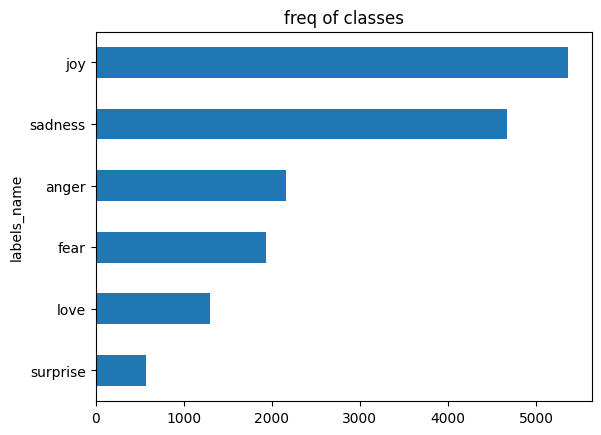

In [15]:
import matplotlib.pyplot as plt
df['labels_name'].value_counts(ascending=True).plot.barh()
plt.title("freq of classes")
plt.show()

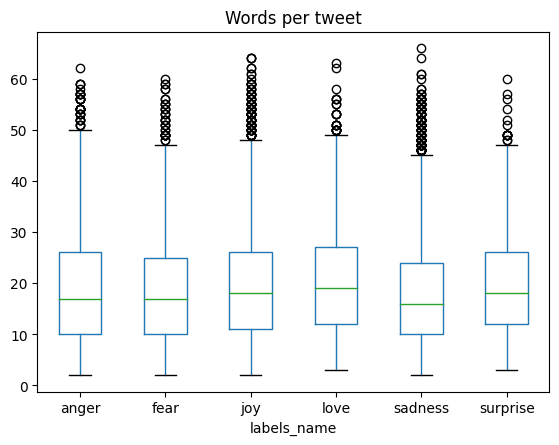

In [16]:
# Length of the document

df['Words per tweet'] = df['text'].str.split(" ").apply(len)
df.boxplot("Words per tweet", by = 'labels_name', grid=False)
plt.suptitle("")
plt.show()

In [17]:
emotion_dataset.reset_format()

 Tokenization - Character tokenization
 Tokenization - Word tokenization
 Goal --> Find a way to effienctly perform the tokenization - Subword Tokenization

In [18]:
from transformers import AutoTokenizer
model = 'distilbert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(model)
# Use the same tokenizer that the model was originally trained with.
# AutoTokenizer is used to load the tokenizer associated with a pre-trained model.

In [19]:
text = "My favorite food is Masala Dosa"
encoded_text = tokenizer(text)
print(encoded_text)

{'input_ids': [101, 2026, 5440, 2833, 2003, 16137, 7911, 9998, 2050, 102], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


In [20]:
type(encoded_text)

transformers.tokenization_utils_base.BatchEncoding

In [21]:
tokens = tokenizer.convert_ids_to_tokens(encoded_text.input_ids)
print(tokens)

['[CLS]', 'my', 'favorite', 'food', 'is', 'mas', '##ala', 'dos', '##a', '[SEP]']


In [22]:
tokenizer.convert_tokens_to_string(tokens)

'[CLS] my favorite food is masala dosa [SEP]'

In [23]:
tokenizer.vocab_size

30522

In [24]:
tokenizer.model_max_length

512

In [25]:
tokenizer.model_input_names

['input_ids', 'attention_mask']

Tokenization on entire dataset

In [26]:
# map()
def tokenization(batch):
  return tokenizer(batch['text'], padding=True, truncation=True)

tokenization(emotion_dataset['train'][:2])

{'input_ids': [[101, 1045, 2134, 2102, 2514, 26608, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [101, 1045, 2064, 2175, 2013, 3110, 2061, 20625, 2000, 2061, 9636, 17772, 2074, 2013, 2108, 2105, 2619, 2040, 14977, 1998, 2003, 8300, 102]], 'attention_mask': [[1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]}

Padding

Purpose: Makes all sequences the same length by adding special tokens (usually [PAD])
When used: When input text is shorter than the required/maximum length
Example: "Hello world" → "Hello world [PAD] [PAD] [PAD]"
Why needed: Neural networks require fixed-size inputs for batch processing


Truncation

Purpose: Cuts text down to fit within maximum token limits
When used: When input exceeds the model's context window or specified max length
Example: A 1000-token text → first 512 tokens only
Strategy options: Truncate from the end, beginning, or middle

In [27]:
emotions_encoded = emotion_dataset.map(tokenization, batched=True, batch_size=None)
emotions_encoded

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 2000
    })
})

Loading the Pre trained Model

In [28]:
!pip install tensorflow

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [29]:
!pip install tf-keras

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [30]:
from transformers import TFAutoModel

model_name = 'distilbert-base-uncased'
model = TFAutoModel.from_pretrained(
    model_name,
    use_safetensors=False  # Force loading from PyTorch format
)

2025-11-20 21:49:26.475798: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763675366.499027     225 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763675366.506090     225 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
I0000 00:00:1763675371.827795     225 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1763675371.828533     225 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability:

TFAutoModel.from_pretrained does three things in one line:

Identifies: It reads the model name (like 'distilbert') and automatically builds the correct TensorFlow/Keras architecture.

Downloads: It fetches the pre-trained weights (the "knowledge") and configuration files from the Hugging Face Hub.

Loads: It sticks those weights into the architecture so the model is ready to use immediately for generating text embeddings.

In [31]:
ex_text ='this a test document'
inputs = tokenizer(ex_text, return_tensors='tf')
print(inputs)

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.


{'input_ids': <tf.Tensor: shape=(1, 6), dtype=int32, numpy=array([[ 101, 2023, 1037, 3231, 6254,  102]], dtype=int32)>, 'attention_mask': <tf.Tensor: shape=(1, 6), dtype=int32, numpy=array([[1, 1, 1, 1, 1, 1]], dtype=int32)>}


What the Output Contains:

input_ids: Token IDs for each word/subword

101 = [CLS] (start token)

2023, 1037, 3231, 6254 = tokens for "this a test document"

102 = [SEP] (end token)

0 = [PAD] (padding if needed)


attention_mask: Indicates which tokens are real vs padding

1 = real token (pay attention)

0 = padding token (ignore)

In [32]:
outputs = model(inputs)
outputs
# Contains contextualized embeddings for each token
# 1 text, 6 tokens, 768 dimensions

TFBaseModelOutput(last_hidden_state=<tf.Tensor: shape=(1, 6, 768), dtype=float32, numpy=
array([[[-0.24797006, -0.20507292,  0.0036957 , ..., -0.17272148,
          0.17205568,  0.35237184],
        [-0.3375831 , -0.24704707,  0.00999898, ..., -0.3119818 ,
          0.5223162 ,  0.26820862],
        [-0.21965718,  0.04554153,  0.15866572, ..., -0.30742165,
          0.12377819,  0.53617203],
        [ 0.35309806, -0.33181846,  0.00846242, ..., -0.6516558 ,
          0.16531816, -0.4173533 ],
        [-0.08453441, -0.16688074, -0.07442554, ..., -0.01995363,
          0.11812012, -0.1066284 ],
        [ 0.8059627 ,  0.08177987, -0.5555365 , ...,  0.12778503,
         -0.67137724, -0.24220622]]], dtype=float32)>, hidden_states=None, attentions=None)

In [33]:
emotions_encoded

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 2000
    })
})

In [34]:
tokenizer.model_input_names

['input_ids', 'attention_mask']

In [35]:
def extract_hidden_states(batch):
  inputs = {k:v for k,v in batch.items() if k in tokenizer.model_input_names}

  last_hidden_state = model(**inputs).last_hidden_state
  return {'hidden_state':last_hidden_state[:,0]}

In [36]:
emotions_encoded

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 2000
    })
})

In [37]:
emotions_encoded.set_format('tensorflow', columns=['input_ids','attention_mask','label'])

In [38]:
emotions_encoded

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 2000
    })
})

In [39]:
emotions_hidden_data = emotions_encoded.map(extract_hidden_states,batched=True)

/usr/local/lib/python3.11/dist-packages/transformers/generation/tf_utils.py:465: UserWarning: `seed_generator` is deprecated and will be removed in a future version.
  warnings.warn("`seed_generator` is deprecated and will be removed in a future version.", UserWarning)


Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Prepare the data with extrated features

Hidden States Act as Features

In [40]:
import numpy as np
X_train = np.array(emotions_hidden_data['train']['hidden_state'])
X_valid = np.array(emotions_hidden_data['validation']['hidden_state'])
y_train = np.array(emotions_hidden_data['train']['label'])
y_valid = np.array(emotions_hidden_data['validation']['label'])
X_train.shape,X_valid.shape

((16000, 768), (2000, 768))

In [41]:
!pip install scikit-learn==1.3.0
!pip install umap-learn==0.5.5

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [42]:
from umap import UMAP
from sklearn.preprocessing import MinMaxScaler
X_scaled = MinMaxScaler().fit_transform(X_train)
mapper = UMAP(n_components=2, metric="cosine").fit(X_scaled)
df_embed = pd.DataFrame(mapper.embedding_, columns=["X", "Y"])
df_embed["label"] = y_train
df_embed.head()

,X,Y,label
0,4.103797,3.501827,0
1,-3.173374,4.500042,0
2,5.500941,6.765231,3
3,-2.450805,6.461877,2
4,-3.455597,6.391994,3


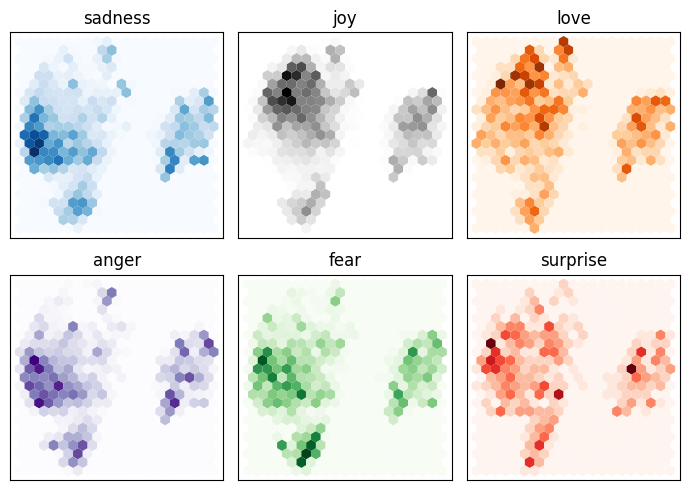

In [43]:
fig, axes = plt.subplots(2, 3, figsize=(7,5))
axes = axes.flatten()
cmaps = ["Blues", "Greys", "Oranges", "Purples", "Greens", "Reds"]
labels = emotion_dataset["train"].features["label"].names
for i, (label, cmap) in enumerate(zip(labels, cmaps)):
    df_embed_sub = df_embed.query(f"label == {i}")
    axes[i].hexbin(df_embed_sub["X"], df_embed_sub["Y"], cmap=cmap,
                   gridsize=20, linewidths=(0,))
    axes[i].set_title(label)
    axes[i].set_xticks([]), axes[i].set_yticks([])
plt.tight_layout()
plt.show()

In [44]:
from sklearn.linear_model import LogisticRegression

In [45]:
lr = LogisticRegression(max_iter= 3000) # 3000 ensures the model has enough iterations to find optimal weights
lr.fit(X_train,y_train)

LogisticRegression(max_iter=3000)

In [46]:
lr.score(X_valid,y_valid)

0.633

In [47]:
from sklearn.dummy import DummyClassifier
dummy_clf = DummyClassifier(strategy='most_frequent')
dummy_clf.fit(X_train,y_train)
dummy_clf.score(X_valid,y_valid)

0.352

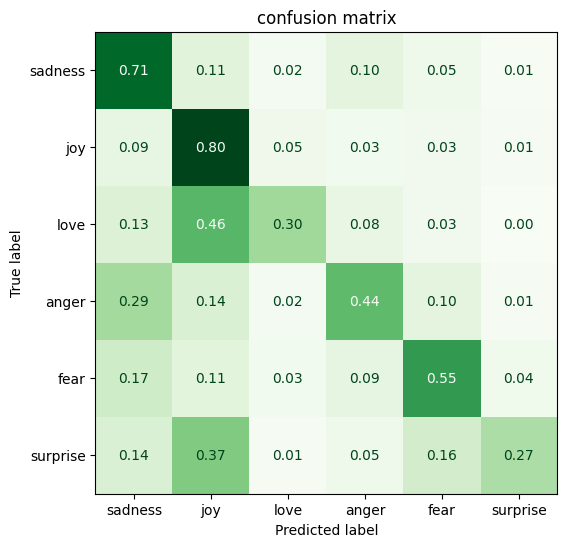

In [48]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

def plot_confusion_matrix(y_preds, y_true, labels):
    cm = confusion_matrix(y_true, y_preds, normalize="true")
    fig, ax = plt.subplots(figsize=(6, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap="Greens", values_format=".2f", ax=ax, colorbar=False)
    plt.title("confusion matrix")
    plt.show()
    
y_preds = lr.predict(X_valid)
plot_confusion_matrix(y_preds, y_valid, labels)

Approach 2: Finetuning on Transformers

In [49]:
from transformers import TFAutoModelForSequenceClassification
num_labels = 6   # Your emotion dataset has 6 emotion categories
tf_model = TFAutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels, use_safetensors=False)

Some layers from the model checkpoint at distilbert-base-uncased were not used when initializing TFDistilBertForSequenceClassification: ['vocab_transform', 'vocab_layer_norm', 'vocab_projector', 'activation_13']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some layers of TFDistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['dropout_38', 'classifier', 'pre_classifier']
You should probably TRAIN this model on a down-stream task to be able to use i

In [50]:
emotions_encoded['validation']['label']

Column([<tf.Tensor: shape=(), dtype=int64, numpy=0>, <tf.Tensor: shape=(), dtype=int64, numpy=0>, <tf.Tensor: shape=(), dtype=int64, numpy=2>, <tf.Tensor: shape=(), dtype=int64, numpy=3>, <tf.Tensor: shape=(), dtype=int64, numpy=1>])

In [58]:
from sklearn.metrics import accuracy_score, f1_score,classification_report

def metrics_compute(pred):
  labels = emotions_encoded['validation']['label']
  predictions = np.argmax(pred,axis=1)
  acc = accuracy_score(labels,predictions)
  cr = classification_report(labels,predictions)
  print(f"accuracy score is {acc}")
  print(f"Classfication report: \n {cr}")

In [ ]:
tokenizer_columns = tokenizer.model_input_names

tf_train_dataset = emotions_encoded['train'].to_tf_dataset(
    columns = tokenizer_columns, 
    label_cols = ['label'],
    shuffle = True,
    batch_size=128
)

tf_test_dataset = emotions_encoded['validation'].to_tf_dataset(
    columns = tokenizer_columns, 
    label_cols = ['label'],
    shuffle = True,
    batch_size=128
)   

/usr/local/lib/python3.11/dist-packages/datasets/arrow_dataset.py:405: FutureWarning: The output of `to_tf_dataset` will change when a passing single element list for `labels` or `columns` in the next datasets version. To return a tuple structure rather than dict, pass a single string.
Old behaviour: columns=['a'], labels=['labels'] -> (tf.Tensor, tf.Tensor)  
             : columns='a', labels='labels' -> (tf.Tensor, tf.Tensor)  
New behaviour: columns=['a'],labels=['labels'] -> ({'a': tf.Tensor}, {'labels': tf.Tensor})  
             : columns='a', labels='labels' -> (tf.Tensor, tf.Tensor) 
  warnings.warn(


In [53]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.metrics import SparseCategoricalAccuracy

In [54]:
from transformers import create_optimizer

# Create optimizer with weight decay
optimizer, schedule = create_optimizer(
    init_lr=5e-5,
    num_warmup_steps=0,
    num_train_steps=len(train_dataset) * 3,  # 3 epochs
    weight_decay_rate=0.01,
)

tf_model.compile(
    optimizer=optimizer,
    metrics=['accuracy']
)

In [55]:
tf_model.fit(tf_train_dataset, validation_data=tf_test_dataset,epochs=2)

Epoch 1/2
125/125 [==============================] - 142s 1s/step - loss: 0.6667 - accuracy: 0.7721 - val_loss: 0.1962 - val_accuracy: 0.9290
Epoch 2/2
125/125 [==============================] - 139s 1s/step - loss: 0.1544 - accuracy: 0.9389 - val_loss: 0.1361 - val_accuracy: 0.9405


In [56]:
pred = tf_model.predict(tf_test_dataset)

16/16 [==============================] - 7s 316ms/step


In [59]:
np.argmax(pred.logits,axis=1)

array([1, 0, 2, ..., 3, 0, 0])

In [60]:
eval = tf_model.evaluate(tf_test_dataset)

16/16 [==============================] - 4s 258ms/step - loss: 0.1361 - accuracy: 0.9405
